# 133 - Jina CLIP v2 のベクトル空間特性分析

## 概要
Jina CLIP v2 (1024-D) と SigLIP 2 Large 256 (1024-D) を **同じ次元・同じデータ・同じクエリ** で並べて、ベクトル空間そのものの性質を比較する。

## 調査軸
1. **モダリティギャップ (Two-Tower 性)**: 画像中心 vs テキスト中心の距離、同意ペア cos vs ランダムペア cos の分布
2. **異方性 (Anisotropy)**: ランダムペア cos 平均、第1主成分寄与率、実効ランク（モダリティ別）
3. **Matryoshka 有効性**: 1024 → 512/256/128/64 への truncate + 再正規化での MRR 劣化曲線

## 比較対象
- **Jina CLIP v2** (XLM-RoBERTa BPE, EVA02 vision)
- **SigLIP 2 Large 256** (Gemma BPE, ViT-L)

## 前提
- NB131 で Jina v2 画像埋め込み済み、`google/siglip2-large-patch16-256` 画像埋め込みも DB に保存済み

In [1]:
from pathlib import Path
import json
from datetime import datetime

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from image_vector_poc import JinaCLIPONNXEmbedder, SigLIP2Embedder

2026-04-14 12:20:37.107214613 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. 画像埋め込みの読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
ONNX_CACHE = Path("../data/jina_clip_v2_onnx")

MODELS = {
    "Jina v2": "jinaai/jina-clip-v2",
    "SigLIP 2 L256": "google/siglip2-large-patch16-256",
}

conn = duckdb.connect(str(DB_PATH), read_only=True)
catalog_df = conn.execute("SELECT id, file_path, category FROM image_catalog ORDER BY id").fetchdf()

image_embeddings = {}
for label, model_name in MODELS.items():
    df = conn.execute("""
        SELECT c.id, e.embedding
        FROM image_catalog c JOIN image_embeddings e ON c.id = e.id
        WHERE e.model_name = ? ORDER BY c.id
    """, [model_name]).fetchdf()
    X = np.array(df['embedding'].tolist(), dtype=np.float32)
    X = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-8, None)
    image_embeddings[label] = X
    print(f"{label}: {X.shape}, dim={X.shape[1]}")
conn.close()

categories = catalog_df['category'].tolist()

Jina v2: (378, 1024), dim=1024
SigLIP 2 L256: (378, 1024), dim=1024


## 2. テキスト埋め込みの生成（NB132 と同じ 18 クエリ）

In [3]:
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
]
queries = [q["query"] for q in test_queries]
print(f"queries: {len(queries)}")

queries: 18


In [4]:
text_embeddings = {}

print("Embedding texts with Jina v2 (ONNX)...")
jina = JinaCLIPONNXEmbedder(dtype="fp32", device="cuda", cache_dir=ONNX_CACHE)
te = jina.embed_texts(queries)
te = te / np.clip(np.linalg.norm(te, axis=1, keepdims=True), 1e-8, None)
text_embeddings["Jina v2"] = te
del jina
import gc; gc.collect()
import torch; torch.cuda.empty_cache()

print("Embedding texts with SigLIP 2 L256 (PyTorch)...")
siglip = SigLIP2Embedder(model_name="google/siglip2-large-patch16-256", device="cuda")
te = siglip.embed_texts(queries)
te = te / np.clip(np.linalg.norm(te, axis=1, keepdims=True), 1e-8, None)
text_embeddings["SigLIP 2 L256"] = te
del siglip
gc.collect(); torch.cuda.empty_cache()

for k, v in text_embeddings.items():
    print(f"  {k}: {v.shape}")

Embedding texts with Jina v2 (ONNX)...


The image processor of type `JinaCLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


`torch_dtype` is deprecated! Use `dtype` instead!


Embedding texts with SigLIP 2 L256 (PyTorch)...


Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  Jina v2: (18, 1024)
  SigLIP 2 L256: (18, 1024)


## 3. モダリティギャップ（Two-Tower 性）

**指標:**
- 画像中心 / テキスト中心間の cos 距離・L2 距離
- ペア cos 分布: (image, expected-text) vs (image, random-text)
- 散布図: 全画像 + 全テキストを 2D PCA で射影

In [5]:
print(f"{'Model':<18} {'centroid_cos_dist':>20} {'centroid_L2_dist':>20} {'avg_img-txt_cos':>20}")
print("-" * 80)
gap_stats = {}
for label in MODELS:
    img = image_embeddings[label]
    txt = text_embeddings[label]
    img_c = img.mean(axis=0)
    txt_c = txt.mean(axis=0)
    img_c_n = img_c / np.linalg.norm(img_c)
    txt_c_n = txt_c / np.linalg.norm(txt_c)
    cos_dist = 1 - float(img_c_n @ txt_c_n)
    l2_dist = float(np.linalg.norm(img_c - txt_c))
    avg_cross = float((img @ txt.T).mean())
    gap_stats[label] = {"cos_dist": cos_dist, "l2_dist": l2_dist, "avg_cross": avg_cross}
    print(f"{label:<18} {cos_dist:>20.4f} {l2_dist:>20.4f} {avg_cross:>20.4f}")

Model                 centroid_cos_dist     centroid_L2_dist      avg_img-txt_cos
--------------------------------------------------------------------------------
Jina v2                          0.7343               0.8752               0.1371
SigLIP 2 L256                    0.9486               1.1289               0.0343


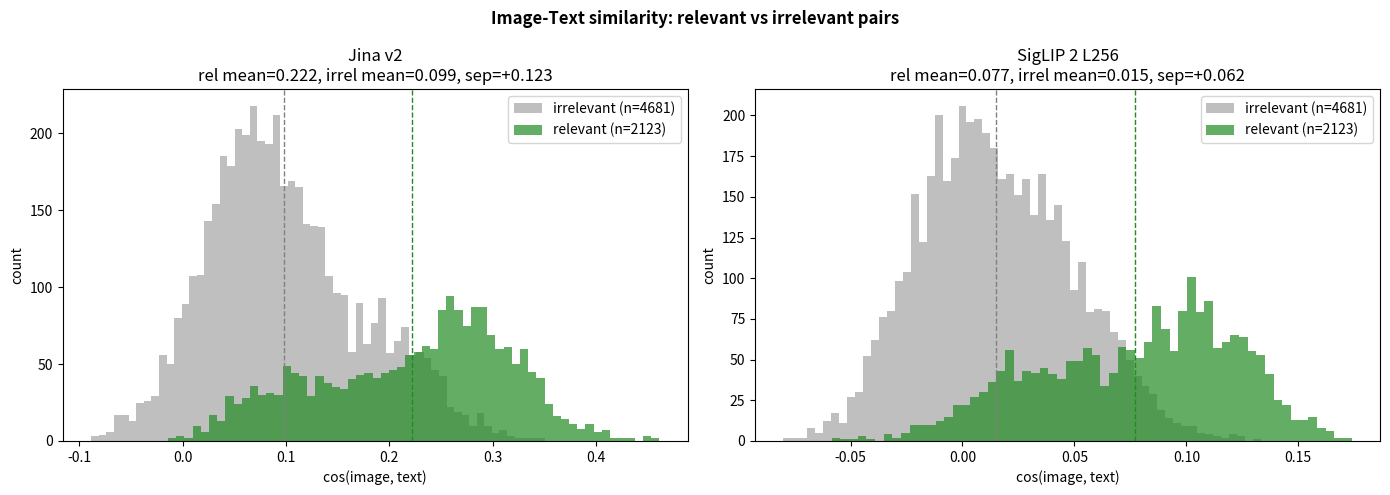

In [6]:
# 同意ペア cos vs 全ペア cos の分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, MODELS):
    img = image_embeddings[label]
    txt = text_embeddings[label]
    sims = img @ txt.T  # (N_img, N_query)
    relevant_mask = np.zeros_like(sims, dtype=bool)
    for j, q in enumerate(test_queries):
        for i, c in enumerate(categories):
            if c in q["expected_categories"]:
                relevant_mask[i, j] = True
    rel = sims[relevant_mask]
    irrel = sims[~relevant_mask]
    ax.hist(irrel, bins=60, alpha=0.5, label=f"irrelevant (n={len(irrel)})", color="gray")
    ax.hist(rel, bins=60, alpha=0.7, label=f"relevant (n={len(rel)})", color="forestgreen")
    ax.axvline(rel.mean(), color="forestgreen", linestyle="--", linewidth=1)
    ax.axvline(irrel.mean(), color="gray", linestyle="--", linewidth=1)
    sep = rel.mean() - irrel.mean()
    ax.set_title(f"{label}\nrel mean={rel.mean():.3f}, irrel mean={irrel.mean():.3f}, sep={sep:+.3f}")
    ax.set_xlabel("cos(image, text)")
    ax.set_ylabel("count")
    ax.legend()
plt.suptitle("Image-Text similarity: relevant vs irrelevant pairs", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_v2_modality_pair_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

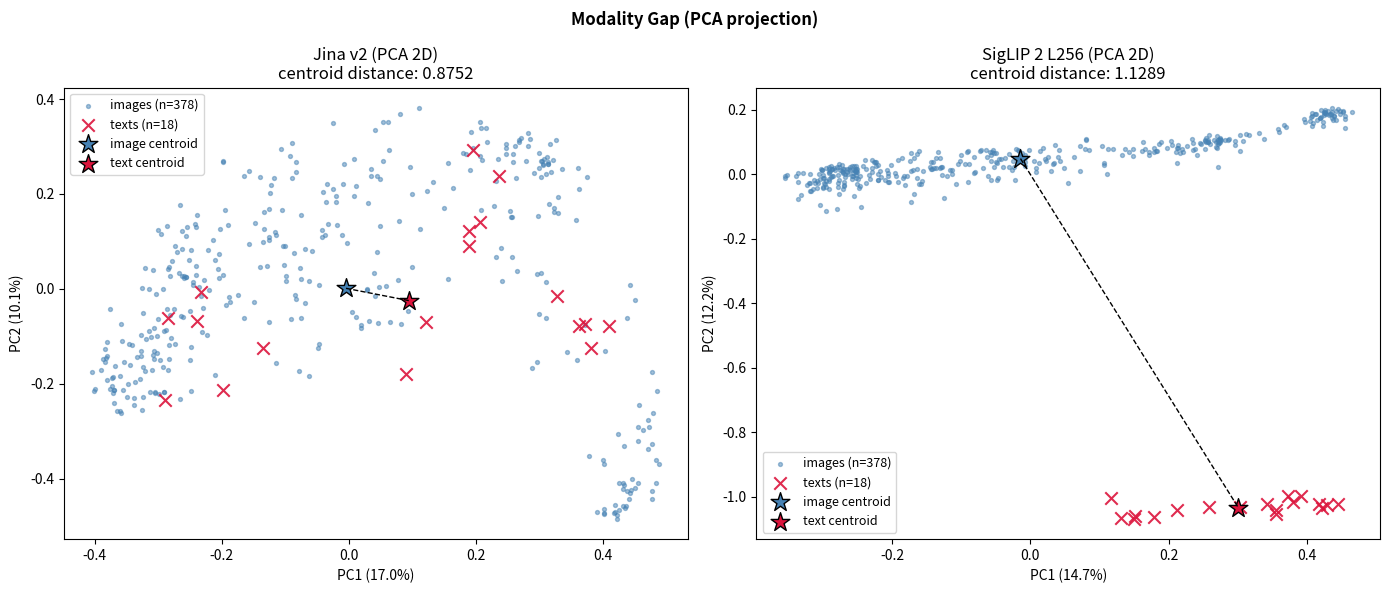

In [7]:
# 2D PCA で 画像 + テキスト を投影し、モダリティギャップを可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label in zip(axes, MODELS):
    img = image_embeddings[label]
    txt = text_embeddings[label]
    combined = np.vstack([img, txt])
    pca = PCA(n_components=2, random_state=42)
    proj = pca.fit_transform(combined)
    img_proj = proj[:len(img)]
    txt_proj = proj[len(img):]
    ax.scatter(img_proj[:, 0], img_proj[:, 1], s=8, alpha=0.5, label=f"images (n={len(img)})", color="steelblue")
    ax.scatter(txt_proj[:, 0], txt_proj[:, 1], s=80, alpha=0.9, label=f"texts (n={len(txt)})", color="crimson", marker="x")
    img_c = img_proj.mean(axis=0)
    txt_c = txt_proj.mean(axis=0)
    ax.scatter(*img_c, s=200, color="steelblue", marker="*", edgecolors="black", label="image centroid")
    ax.scatter(*txt_c, s=200, color="crimson", marker="*", edgecolors="black", label="text centroid")
    ax.plot([img_c[0], txt_c[0]], [img_c[1], txt_c[1]], 'k--', linewidth=1)
    ax.set_title(f"{label} (PCA 2D)\ncentroid distance: {gap_stats[label]['l2_dist']:.4f}")
    ax.legend(loc="best", fontsize=9)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.suptitle("Modality Gap (PCA projection)", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_v2_modality_gap_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 異方性 (Anisotropy)

**指標:**
- ランダムペア cos 平均（0=等方、>0=異方）
- PC1 寄与率（1 方向への偏り）
- 実効ランク（singular value entropy 由来）— 実質使われている次元数

画像とテキストを別々に測ることで、Two-Tower の各塔の異方性を比較する。

In [8]:
def anisotropy_metrics(X, n_pairs=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X)
    if n < 2:
        return {"rand_cos": float('nan'), "pc1": float('nan'), "pc10_cum": float('nan'), "eff_rank": float('nan')}
    actual_pairs = min(n_pairs, n * (n - 1) // 2)
    pairs = rng.choice(n, size=(actual_pairs * 2, 2))
    pairs = pairs[pairs[:, 0] != pairs[:, 1]][:actual_pairs]
    rand_cos = float((X[pairs[:, 0]] * X[pairs[:, 1]]).sum(axis=1).mean())
    pca = PCA(n_components=min(50, X.shape[0] - 1, X.shape[1]))
    pca.fit(X)
    pc1 = float(pca.explained_variance_ratio_[0])
    pc10 = float(pca.explained_variance_ratio_[:10].sum())
    sv = pca.singular_values_
    p = sv ** 2 / (sv ** 2).sum()
    eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return {"rand_cos": rand_cos, "pc1": pc1, "pc10_cum": pc10, "eff_rank": eff_rank}

rows = []
for label in MODELS:
    for modality, X in [("image", image_embeddings[label]), ("text", text_embeddings[label])]:
        m = anisotropy_metrics(X)
        rows.append({"model": label, "modality": modality, "n": len(X), "dim": X.shape[1], **m})
aniso_df = pd.DataFrame(rows)
print("=== 異方性指標 ===")
print(aniso_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

=== 異方性指標 ===
        model modality   n  dim  rand_cos    pc1  pc10_cum  eff_rank
      Jina v2    image 378 1024    0.5847 0.1879    0.5748   22.9683
      Jina v2     text  18 1024    0.4396 0.2694    0.9055    9.5228
SigLIP 2 L256    image 378 1024    0.5950 0.1693    0.5220   24.0001
SigLIP 2 L256     text  18 1024    0.7388 0.2055    0.8564   11.9657


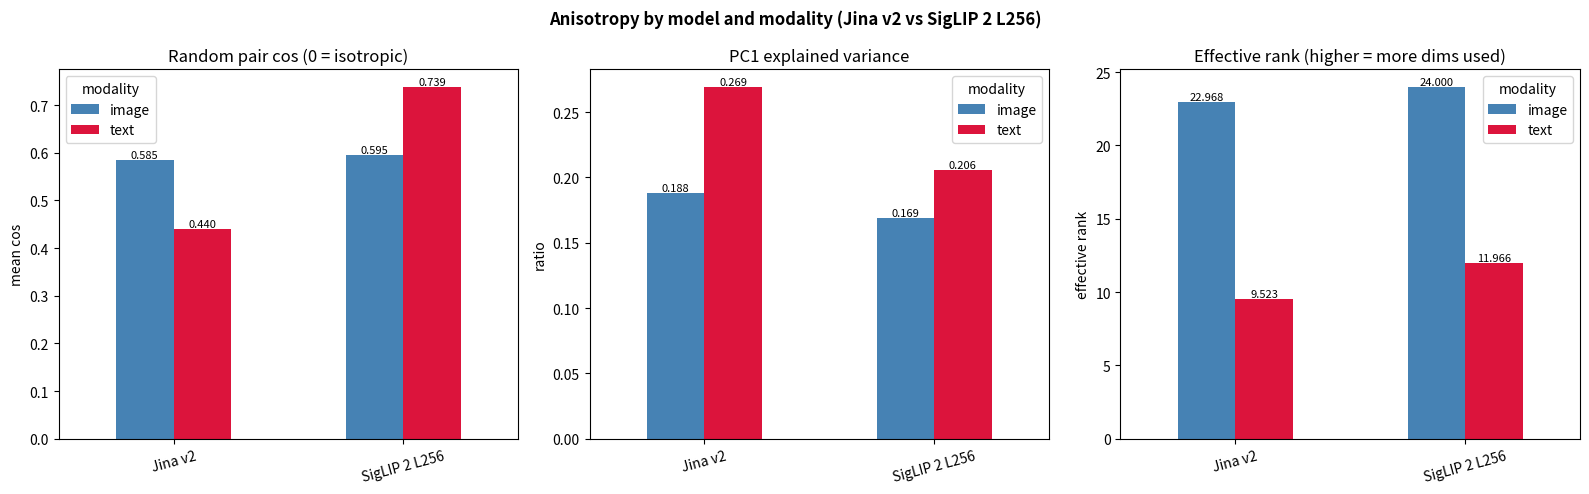

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title, ylabel in [
    (axes[0], "rand_cos", "Random pair cos (0 = isotropic)", "mean cos"),
    (axes[1], "pc1", "PC1 explained variance", "ratio"),
    (axes[2], "eff_rank", "Effective rank (higher = more dims used)", "effective rank"),
]:
    pivot = aniso_df.pivot(index="model", columns="modality", values=metric)
    pivot.plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.suptitle("Anisotropy by model and modality (Jina v2 vs SigLIP 2 L256)", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_v2_anisotropy.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Matryoshka 有効性: truncate + 再正規化 → MRR 劣化曲線

**手順:**
- 1024 → 768/512/384/256/192/128/96/64/48/32 へ先頭次元から truncate
- 再正規化
- NB132 と同じ 18 クエリで MRR を再計算
- Jina v2（公式 Matryoshka 対応）と SigLIP 2 L256（非対応, 比較対照）の劣化を比較

In [10]:
DIMS = [1024, 768, 512, 384, 256, 192, 128, 96, 64, 48, 32]

def mrr_at_dim(img, txt, dim):
    img_t = img[:, :dim]
    img_t = img_t / np.clip(np.linalg.norm(img_t, axis=1, keepdims=True), 1e-8, None)
    txt_t = txt[:, :dim]
    txt_t = txt_t / np.clip(np.linalg.norm(txt_t, axis=1, keepdims=True), 1e-8, None)
    sims = img_t @ txt_t.T  # (N_img, N_query)
    mrr_list, mrr_en, mrr_ja = [], [], []
    for j, q in enumerate(test_queries):
        order = np.argsort(sims[:, j])[::-1]
        rr = 0.0
        for rank, idx in enumerate(order, start=1):
            if categories[idx] in q["expected_categories"]:
                rr = 1.0 / rank
                break
        mrr_list.append(rr)
        (mrr_en if q["lang"] == "en" else mrr_ja).append(rr)
    return float(np.mean(mrr_list)), float(np.mean(mrr_en)), float(np.mean(mrr_ja))

rows = []
for label in MODELS:
    img = image_embeddings[label]
    txt = text_embeddings[label]
    for d in DIMS:
        m_all, m_en, m_ja = mrr_at_dim(img, txt, d)
        rows.append({"model": label, "dim": d, "MRR_overall": m_all, "MRR_en": m_en, "MRR_ja": m_ja})
matry_df = pd.DataFrame(rows)
display(matry_df.pivot(index="dim", columns="model", values=["MRR_overall", "MRR_en", "MRR_ja"]).round(4).sort_index(ascending=False))

MRR_overall                MRR_en                MRR_ja              
model     Jina v2 SigLIP 2 L256 Jina v2 SigLIP 2 L256 Jina v2 SigLIP 2 L256
dim                                                                        
1024       0.8812        0.9278  0.8958        0.8917  0.8519        1.0000
768        0.8534        0.8542  0.8542        0.8646  0.8519        0.8333
512        0.8812        0.9352  0.8958        0.9583  0.8519        0.8889
384        0.8580        0.8519  0.8611        0.8611  0.8519        0.8333
256        0.8588        0.8531  0.8611        0.9028  0.8542        0.7538
192        0.9144        0.7632  0.9444        0.8403  0.8542        0.6092
128        0.7857        0.6867  0.8056        0.7441  0.7460        0.5718
96         0.8630        0.6884  0.8611        0.7403  0.8667        0.5845
64         0.8815        0.6510  0.8889        0.7619  0.8667        0.4292
48         0.9556        0.4927  0.9333        0.5938  1.0000        0.2903
32         0.9722        0.4752  0.9583        0.6058  1.0000        0.2140

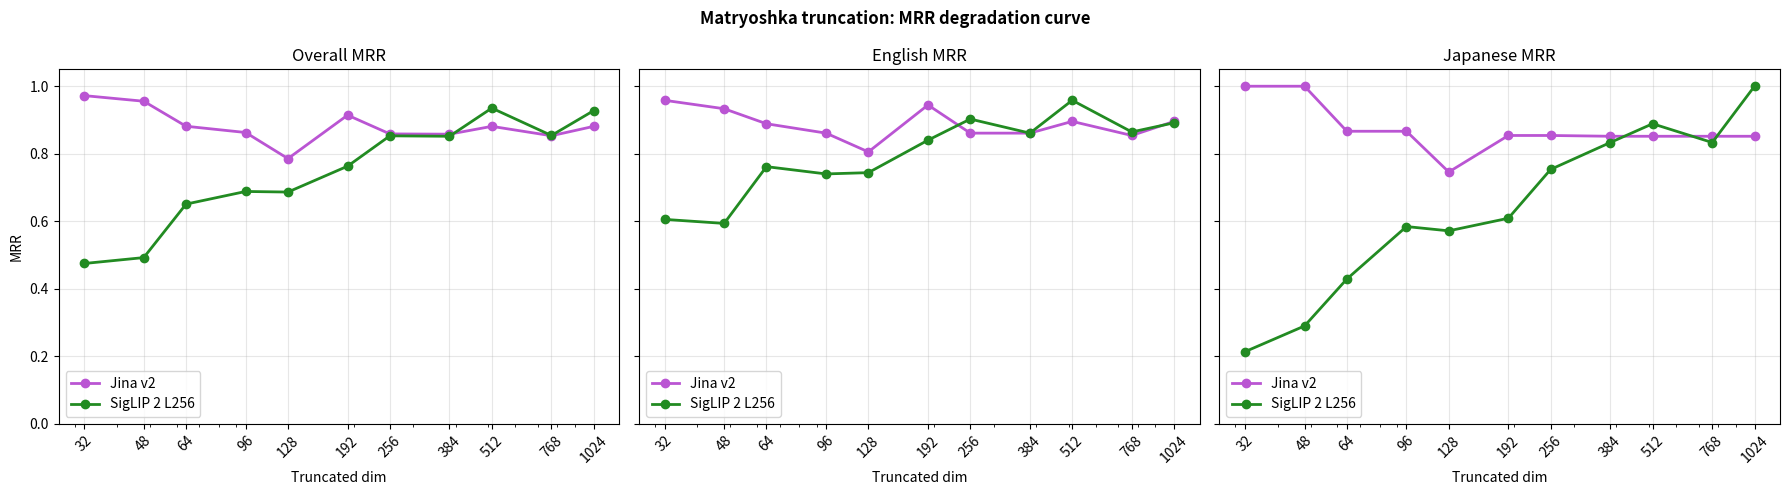

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, col, title in [
    (axes[0], "MRR_overall", "Overall MRR"),
    (axes[1], "MRR_en", "English MRR"),
    (axes[2], "MRR_ja", "Japanese MRR"),
]:
    for label, color in zip(MODELS, ["mediumorchid", "forestgreen"]):
        sub = matry_df[matry_df["model"] == label].sort_values("dim")
        ax.plot(sub["dim"], sub[col], marker="o", label=label, color=color, linewidth=2)
    ax.set_xscale("log")
    ax.set_xticks(DIMS)
    ax.set_xticklabels(DIMS, rotation=45)
    ax.set_xlabel("Truncated dim")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("MRR")
plt.suptitle("Matryoshka truncation: MRR degradation curve", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_v2_matryoshka_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 結果の保存

In [12]:
out = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "modality_gap": gap_stats,
    "anisotropy": aniso_df.to_dict(orient="records"),
    "matryoshka": matry_df.to_dict(orient="records"),
}
out_path = Path("../data/evaluations") / f"133_jina_clip_v2_vector_space_{datetime.now().strftime('%Y-%m-%d')}.json"
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f"Saved: {out_path}")

Saved: ../data/evaluations/133_jina_clip_v2_vector_space_2026-04-14.json


## まとめ・考察

Jina CLIP v2 と SigLIP 2 Large 256（どちらも 1024-D）のベクトル空間を、同じ 378 画像 + 18 クエリで並べて比較した。

### モダリティギャップ

| モデル | centroid cos 距離 | L2 距離 | avg img-txt cos |
|---|---:|---:|---:|
| **Jina v2** | 0.734 | 0.875 | 0.137 |
| **SigLIP 2 L256** | 0.949 | 1.129 | 0.034 |

- **直感に反する結果**: SigLIP 2 の方が画像塔とテキスト塔の中心が離れているのに、MRR は SigLIP 2 の方が高い
- **示唆**: 「モダリティギャップが小さい＝検索性能が良い」は単純には成立しない。Jina は画像とテキストが近い空間に配置されているが、テキスト同士の識別性で負けている可能性

### 異方性

| モデル | 画像 rand_cos | テキスト rand_cos | 画像 eff_rank | テキスト eff_rank |
|---|---:|---:|---:|---:|
| **Jina v2** | 0.585 | **0.440** | 23.0 | 9.5 |
| **SigLIP 2 L256** | 0.595 | **0.739** | 24.0 | 12.0 |

- 画像塔は両モデルでほぼ同じ異方性（rand_cos ~0.59）
- **SigLIP 2 のテキスト塔は強烈に異方的（0.74）** — テキスト同士が狭いコーンに集中
- Jina v2 のテキスト塔はより広く分散（0.44）
- 両モデルとも実効ランクは 1024 次元中 ~25 程度しか使っていない（典型的な contrastive モデル）

### Matryoshka truncation の MRR 劣化曲線

| dim | **Jina v2** | **SigLIP 2 L256** |
|---:|---:|---:|
| 1024 | 0.881 | 0.928 |
| 512 | 0.881 | 0.935 |
| 256 | 0.859 | 0.853 |
| 128 | 0.786 | 0.687 |
| 64 | **0.882** | 0.651 |
| 32 | **0.972** ★★ | 0.475 |

- **Jina v2 は次元削減で MRR がむしろ改善**（1024: 0.881 → 32: **0.972**）。これは公式 Matryoshka 訓練の効果
- **SigLIP 2 L256 は Matryoshka 非対応で 256 以下から急速に崩壊**（1024: 0.928 → 32: 0.475、約半減）
- **32 次元の Jina v2 は JA MRR も 1.000 を達成**（SigLIP 2 L256 の 1024 次元と同等）

### 実用的含意

- **ストレージ最適化**: Jina v2 を 32 次元で運用すれば、1024 次元比で **容量 1/32**・検索速度大幅向上・品質はむしろ良くなる
- **SigLIP 2 L256 は 1024 次元で使うべき**（Matryoshka 訓練されていないので truncate すると品質が崩れる）
- **100 万枚超のスケールで差が効く**: 1024×4bytes=4KB/vec vs 32×4bytes=128B/vec → 100 万件で 4GB vs 128MB

### 次のノートブック
- **NB134**: プロンプト工学で JA MRR 0.852 を救えるか
